In [139]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

folder_path = Path.cwd() / "OfflinePreprocessingComparison"
results_file_path = folder_path / "OfflineValidationResults_PreprocessingComparison.csv"

In [140]:
df = pd.read_csv(str(results_file_path.absolute()), sep=";")

df.rename(columns={"S / F": "sliding_fixed", "initial left offset [ms]": "offset", "step size": "step_size"}, inplace=True)
df.columns = df.columns.str.replace(' ', '')

df["step_size"] = df['step_size'].fillna(0)

In [141]:
#grouped_df = df.groupby(["Model", "sliding_fixed", "step_size"])
#for (model, sliding_fixed, step_size), group_df in grouped_df:
#    df_melted = group_df.drop(["Model", "sliding_fixed", "step_size"], axis=1).melt(
#        id_vars=['offset'], var_name='majority_voting', value_name='values')
#
#    plt.figure()
#
#    sns.catplot(data=df_melted, x='offset', y='values', hue='majority_voting',
#                kind='bar', height=6, aspect=1.5, palette="colorblind", legend_out=False)
#
#    average_accuracy = df_melted['values'].mean()
#    highest_accuracy = df_melted['values'].max()
#
#    plt.axhline(y=average_accuracy, color='b', linestyle='--',
#                label='Average Accuracy', alpha=0.75)
#    plt.axhline(y=highest_accuracy, color='g', linestyle='--',
#                label='Highest Accuracy', alpha=0.75)
#    plt.text(3.55 if sliding_fixed == "F" else 5.6, average_accuracy, f'{average_accuracy:.2f}%',
#             color='b', fontsize=10, va='center', ha='left')
#    plt.text(3.55 if sliding_fixed == "F" else 5.6, highest_accuracy, f'{highest_accuracy:.2f}%',
#             color='g', fontsize=10, va='center', ha='left')
#
#    title = f"{model} Models, {'fixed' if sliding_fixed == 'F' else 'sliding'} window"
#    title += f", step size Δs = {int(step_size)}" if sliding_fixed == 'S' else ""
#    plt.title(title)
#
#    plt.xlabel('Offset Δo [ms]')
#
#    plt.ylabel('Accuracy [%]')
#    # plt.grid(True, axis='y', linestyle='--', alpha=0.5)
#
#    plt.legend(loc='lower right', bbox_to_anchor=(1.25, 0))
#    for text in plt.gca().get_legend().get_texts():
#        text.set_text(text.get_text().replace('SV', 'Soft Voting $N_p$ = '))
#        text.set_text(text.get_text().replace('HV', 'Hard Voting $N_p$ = '))
#
#    step_size_suffix = f"_step{int(step_size)}" if sliding_fixed == 'S' else ""
#    filename = f"{model}_{'fixed' if sliding_fixed == 'F' else 'sliding'}{step_size_suffix}.png"
#    #plt.savefig(Path.cwd() / "OfflinePreprocessingComparison" /
#                #filename, bbox_inches='tight')
#
#    plt.close()
#    plt.show()

In [142]:
df_preprocessing = df.copy()

conditions = [
    df_preprocessing["Model"].isin(["GRU", "Transformer"]),
    df_preprocessing["Model"] == "LSTM"]
choices = [df_preprocessing["HV15"], df_preprocessing["HV8"]]

df_preprocessing["Accuracy"] = pd.Series(
    np.select(conditions, choices, default=None))

columns_to_drop = [col for col in df_preprocessing.columns if col.startswith(
    "SV") or col.startswith("HV")]
df_preprocessing = df_preprocessing.drop(columns=columns_to_drop)

GRU model accuracies:


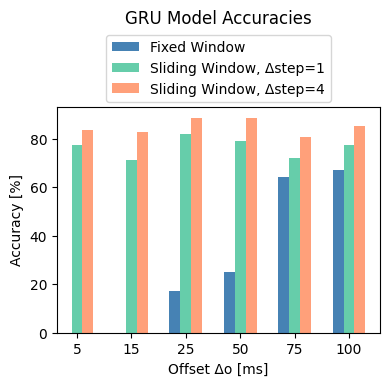

LSTM model accuracies:


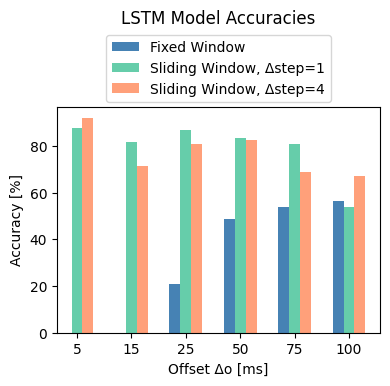

Transformer model accuracies:


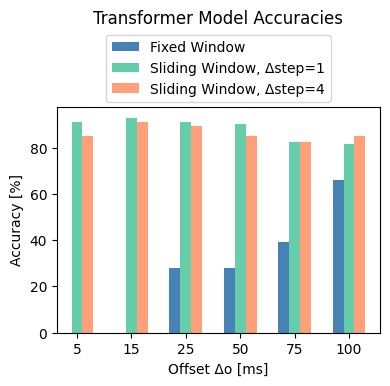

In [143]:
def plot_preprocessing_comparison(model, model_df, plot_vertical=False):
    model_df_fixed = model_df[model_df['sliding_fixed'] == 'F']
    model_df_sliding_step1 = model_df[(
        model_df['sliding_fixed'] == 'S') & (model_df['step_size'] == 1)]
    model_df_sliding_step4 = model_df[(
        model_df['sliding_fixed'] == 'S') & (model_df['step_size'] == 4)]

    model_df_grouped = pd.DataFrame({
        'offset': model_df['offset'].unique(),
        'fixed_acc': model_df_fixed.groupby('offset')['Accuracy'].max(),
        'sliding_step1_acc': model_df_sliding_step1.groupby('offset')['Accuracy'].max(),
        'sliding_step4_acc': model_df_sliding_step4.groupby('offset')['Accuracy'].max(),
    })

    fig, ax = plt.subplots(figsize=(4, 4))

    bar_width = 0.2

    r1 = np.arange(len(model_df_grouped))
    r2 = [x + bar_width for x in r1]
    r3 = [x + bar_width for x in r2]

    ax.set_xlabel('Offset Δo [ms]')
    ax.set_ylabel('Accuracy [%]')
    ax.set_xticks([r + bar_width for r in range(len(model_df_grouped))])
    ax.set_xticklabels(model_df_grouped['offset'])

    # Bar plots
    ax.bar(r1, model_df_grouped['fixed_acc'], color='#4682B4',
           width=bar_width, label='Fixed')
    
    ax.bar(r2, model_df_grouped['sliding_step1_acc'], color='#66CDAA',
           width=bar_width, label='Sliding Step 1')
    
    ax.bar(r3, model_df_grouped['sliding_step4_acc'], color='#FFA07A',
           width=bar_width, label='Sliding Step 4')  # LightSalmon
    
    ax.set_xlabel('Offset Δo [ms]')
    ax.set_ylabel('Accuracy [%]')

    ax.set_xticks([r + bar_width for r in range(len(model_df_grouped))])
    ax.set_xticklabels(model_df_grouped['offset'])

    ax.set_title(f"{model} Model Accuracies", pad=60)

    legend = ['Fixed Window', 'Sliding Window, Δstep=1', 'Sliding Window, Δstep=4']
    ax.legend(legend, loc='upper center', bbox_to_anchor=(0.5, 1.35), ncol=1)

    plt.tight_layout()

    print(f"{model} model accuracies:")

    plt.savefig(Path.cwd() / "OfflinePreprocessingComparison" /
                f"{model}_Accuracies_PreprocessingComparison.png", bbox_inches='tight', dpi=300)
    plt.show()


#plot_preprocessing_comparison("AllModels", df)
for model, model_df in df_preprocessing.groupby("Model"):
    plot_preprocessing_comparison(model, model_df)

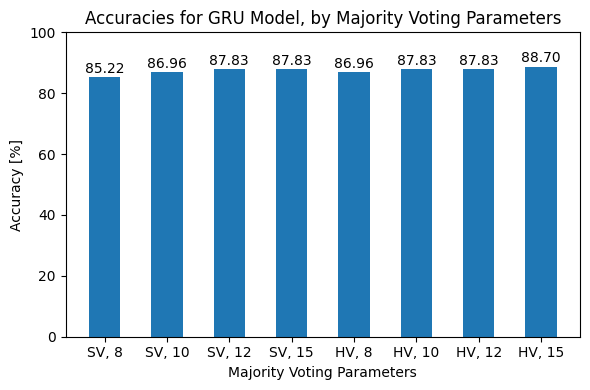

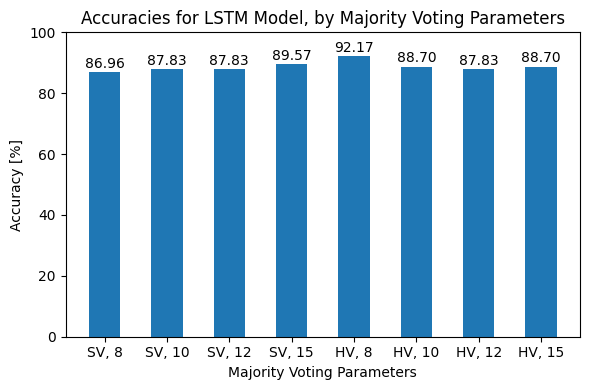

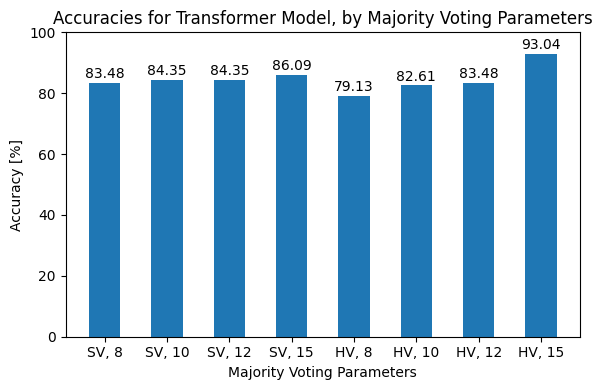

In [144]:
sliding_window_df = df[df["sliding_fixed"] == "S"]
sliding_window_df = sliding_window_df[
    ((sliding_window_df["Model"] == "GRU") & (sliding_window_df["offset"] == 50) & (sliding_window_df["step_size"] == 4)) |
    ((sliding_window_df["Model"] == "LSTM") & (sliding_window_df["offset"] == 5) & (sliding_window_df["step_size"] == 4)) |
    ((sliding_window_df["Model"] == "Transformer") & (
        sliding_window_df["offset"] == 15) & (sliding_window_df["step_size"] == 1))
]

value_columns = [col for col in sliding_window_df.columns if col.startswith(
    "SV") or col.startswith("HV")]
for index, row in sliding_window_df.iterrows():
    values = row[value_columns]
    plt.figure(figsize=(6, 4))
    plt.bar(value_columns, values, width=0.5)

    for i, v in enumerate(values):
        plt.text(i, v + 0.5, f"{v:.2f}", ha="center",
                 va="bottom", fontsize=10)

    plt.title(
        f"Accuracies for {row['Model']} Model, by Majority Voting Parameters")
    plt.xlabel("Majority Voting Parameters")
    plt.ylabel("Accuracy [%]")
    plt.ylim(0, 100)
    plt.xticks()
    plt.xticks(ticks=range(len(value_columns)), labels=[
               f"{col[:2]}, {col[2:]}" for col in value_columns])

    plt.tight_layout()
    plt.savefig(Path.cwd() / "OfflinePreprocessingComparison" /
                f"Accuracies_MajorityVotingComparison_{row['Model']}.png", bbox_inches='tight', dpi=300)

    plt.show()

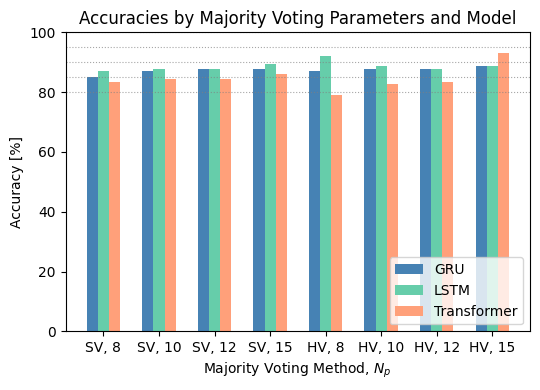

In [157]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Filter dataset for selected rows
sliding_window_df = df[df["sliding_fixed"] == "S"]
sliding_window_df = sliding_window_df[
    ((sliding_window_df["Model"] == "GRU") & (sliding_window_df["offset"] == 50) & (sliding_window_df["step_size"] == 4)) |
    ((sliding_window_df["Model"] == "LSTM") & (sliding_window_df["offset"] == 5) & (sliding_window_df["step_size"] == 4)) |
    ((sliding_window_df["Model"] == "Transformer") & (sliding_window_df["offset"] == 15) & (sliding_window_df["step_size"] == 1))
]

# Majority voting parameter columns
value_columns = [col for col in sliding_window_df.columns if col.startswith("SV") or col.startswith("HV")]

# Define models and colors
models = ["GRU", "LSTM", "Transformer"]
colors = ["#4682B4", "#66CDAA", "#FFA07A"]  # Blue, MediumAquamarine, LightSalmon
bar_width = 0.2

# X locations for the groups
x = np.arange(len(value_columns))

fig, ax = plt.subplots(figsize=(5.5, 4))

# Plot bars for each model
for i, (model, color) in enumerate(zip(models, colors)):
    model_values = sliding_window_df[sliding_window_df["Model"] == model][value_columns].values.flatten()
    ax.bar(x + i * bar_width, model_values, width=bar_width, label=model, color=color)

# X-axis labels
ax.set_xticks(x + bar_width)  # Center labels between grouped bars
ax.set_xticklabels([f"{col[:2]}, {col[2:]}" for col in value_columns])

# Labels and title
ax.set_xlabel("Majority Voting Method, $N_p$")
ax.set_ylabel("Accuracy [%]")
ax.set_title("Accuracies by Majority Voting Parameters and Model")
ax.set_ylim(0, 100)

# Add horizontal lines at key percentages (80%, 85%, 90%, 95%, 100%)
for y in range(80, 105, 5):
    ax.axhline(y=y, color="gray", linestyle=":", linewidth=0.8, alpha=0.7)

# Legend placement outside the plot
ax.legend(loc="lower right", frameon=True)  # Moves legend outside

plt.tight_layout()
plt.savefig(Path.cwd() / "OfflinePreprocessingComparison" / "Accuracies_MajorityVotingComparison.png",
            bbox_inches='tight', dpi=300)

plt.show()